In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [2]:
dat = pd.read_csv(r"E:\DATA FOR TEST\New Churn Data\Churn_Modelling_0.csv")
data = dat.copy()

In [3]:
print(data.info())
print(data.describe())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# All Value Correlation
data_new = data.drop(columns = ["Surname", "Geography", "Gender", "RowNumber", "CustomerId"])
data_new.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [5]:
# Only calculate correlation for columns that are numbers
numeric_data = data_new.select_dtypes(include=['number'])
print(numeric_data.corr()["Exited"])

CreditScore       -0.027094
Age                0.285323
Tenure            -0.014001
Balance            0.118533
NumOfProducts     -0.047820
HasCrCard         -0.007138
IsActiveMember    -0.156128
EstimatedSalary    0.012097
Exited             1.000000
Name: Exited, dtype: float64


In [6]:
# Single Value Correlation
data_new.corr()["Exited"]

CreditScore       -0.027094
Age                0.285323
Tenure            -0.014001
Balance            0.118533
NumOfProducts     -0.047820
HasCrCard         -0.007138
IsActiveMember    -0.156128
EstimatedSalary    0.012097
Exited             1.000000
Name: Exited, dtype: float64

In [7]:
# Single Value Coparision correlation
data["Exited"].corr(data["Age"])

0.2853230378350683

In [8]:
# Create the correlation matrix
corr_matrix = numeric_data.corr()

In [9]:
# Method 1

# 1. Flatten the matrix into a list of pairs
pairs = corr_matrix.unstack()

# 2. Remove the self-correlations (where the value is exactly 1.0)
# We filter for values less than 1.0
actual_relationships = pairs[pairs < 1.0]

# 3. Find Max and Min
max_corr = actual_relationships.max()
min_corr = actual_relationships.min()

print(f"Maximum Correlation (excluding self): {max_corr}")
print(f"Minimum Correlation: {min_corr}")

Maximum Correlation (excluding self): 0.2853230378350698
Minimum Correlation: -0.3041797383605498


In [10]:
# Method 2

# Replace 1.0 with NaN so the computer ignores them
filtered_matrix = corr_matrix.replace(1.0, np.nan)

# Find the values
print("Max correlation:", filtered_matrix.max().max())
print("Min correlation:", filtered_matrix.min().min())

Max correlation: 0.2853230378350698
Min correlation: -0.3041797383605498


In [11]:
# This tells you the names of the columns with the highest relationship
print(actual_relationships.idxmax())
print(actual_relationships.idxmin())

('Age', 'Exited')
('Balance', 'NumOfProducts')


# Correlation Visulization

In [12]:
# Simple Single Value Visulization
# plt.figure()
# numeric_data.corr()["Exited"].sort_values(ascending = False).plot(kind = "bar")

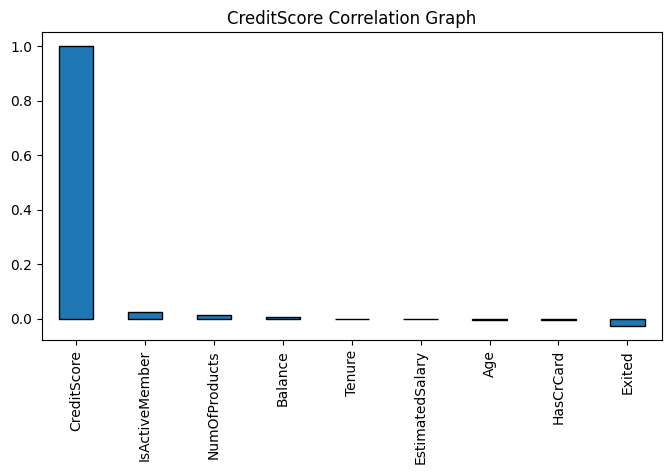

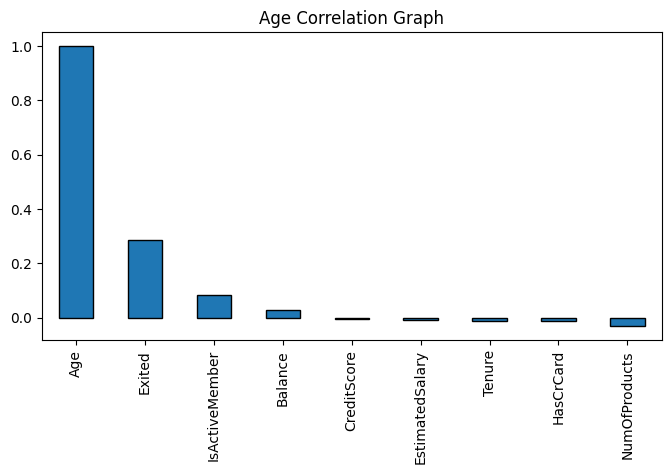

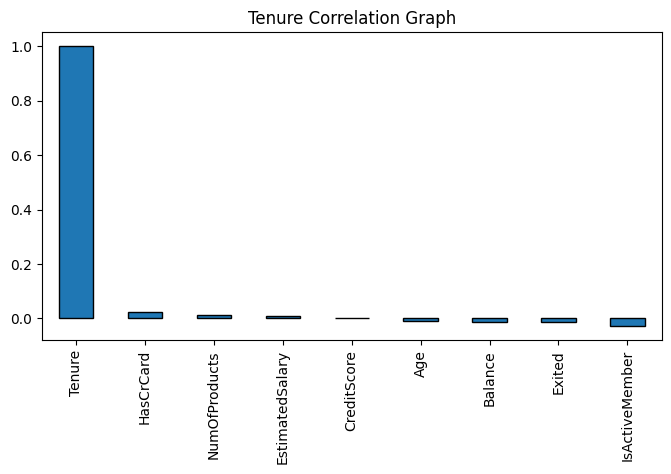

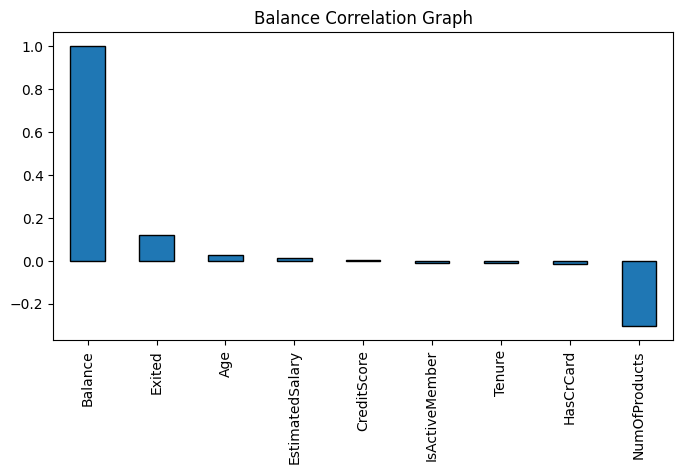

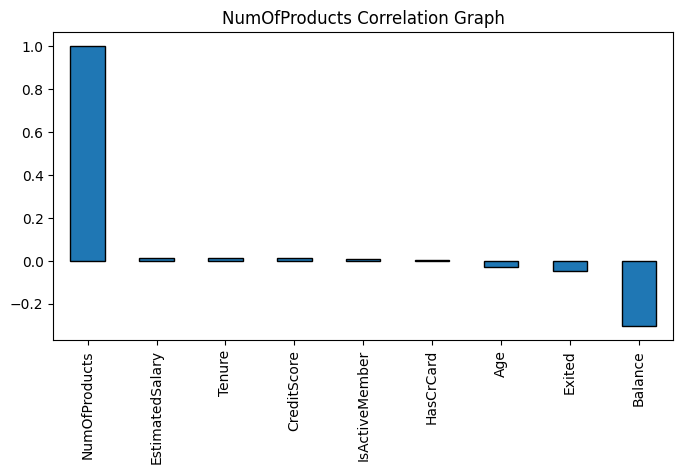

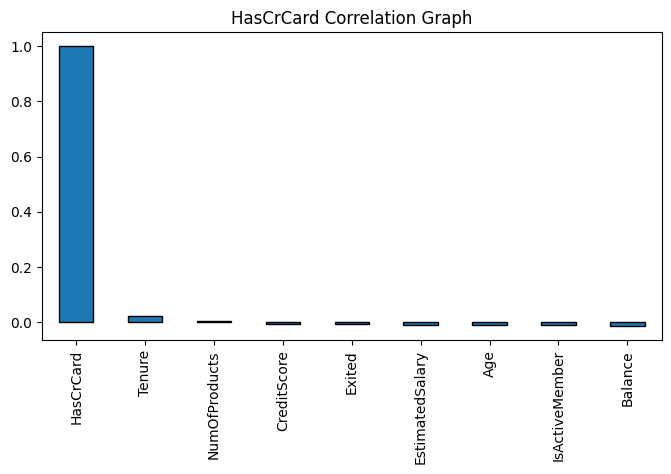

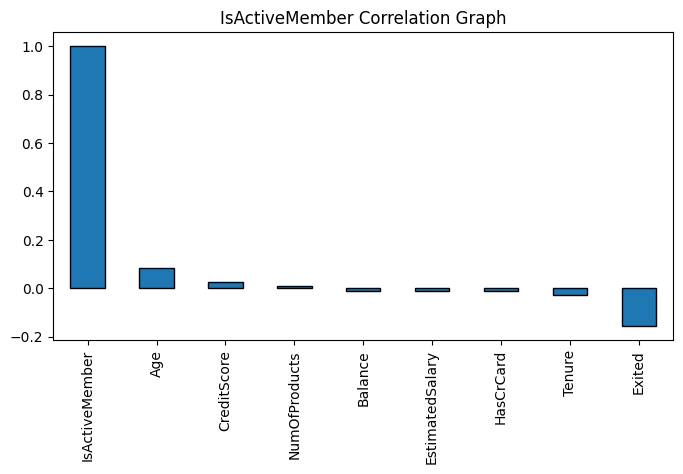

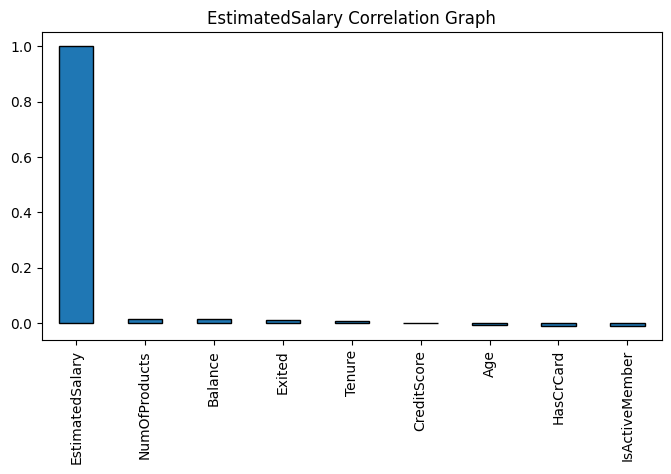

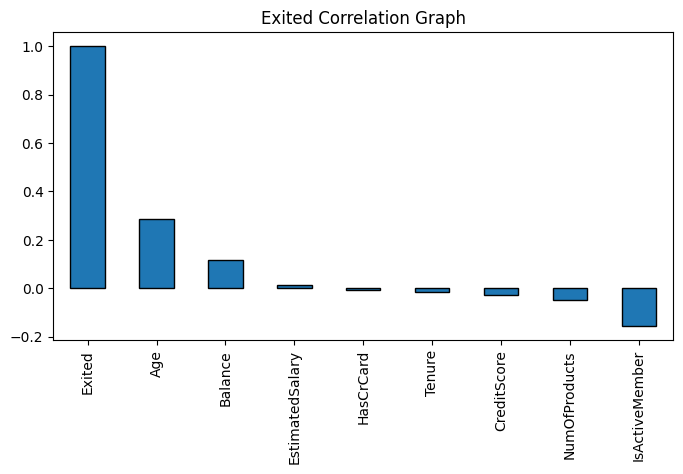

In [15]:
# Same For all Charts
def corr_charts(df):
    for col in df.columns:
        plt.figure(figsize = (8, 4))
        df.corr()[col].sort_values(ascending = False).plot(kind = "bar", edgecolor = "Black")
        plt.title(f"{col} Correlation Graph")
        plt.show()


corr_charts(numeric_data)

In [14]:
numeric_data.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

<Axes: >

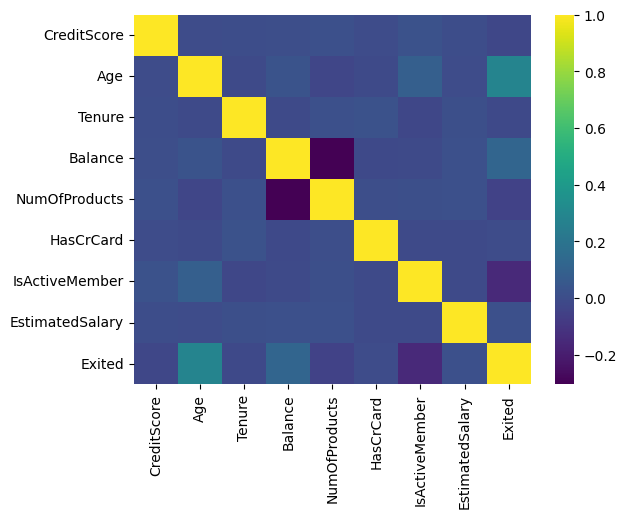

In [15]:
sns.heatmap(data = numeric_data.corr(), cmap = "viridis")
# print(plt.colormaps()) # For Diffrenct Type of cmap

In [16]:
# Function For all Diffrent Cmap
def diff_Cmap(df):
    corr_matrix = df.corr()
    maps = plt.colormaps()    
    for color in maps:
        plt.figure(figsize=(8, 6))
        plt.title(f"Colormap: {color}", fontsize=15)
        sns.heatmap(data=corr_matrix, cmap=color, annot=True)
        plt.show()

# diff_Cmap(numeric_data)

In [17]:
def diff_Cmap(df):
    # 1. Calculate correlation ONCE outside the loop
    corr_matrix = df.corr()
    
    # Get maps (slicing [:5] to avoid printing 160+ plots at once)
    maps = plt.colormaps()[:5] 
    
    for color in maps:
        # 2. Create a new figure for each plot
        plt.figure(figsize=(8, 6))
        
        # 3. Add title so you know which cmap you are looking at
        plt.title(f"Colormap: {color}", fontsize=15)
        
        sns.heatmap(data=corr_matrix, cmap=color, annot=True)
        
        # 4. Explicitly show the plot
        plt.show()

# Usage:
# diff_Cmap(your_dataframe)

<Axes: xlabel='Age'>

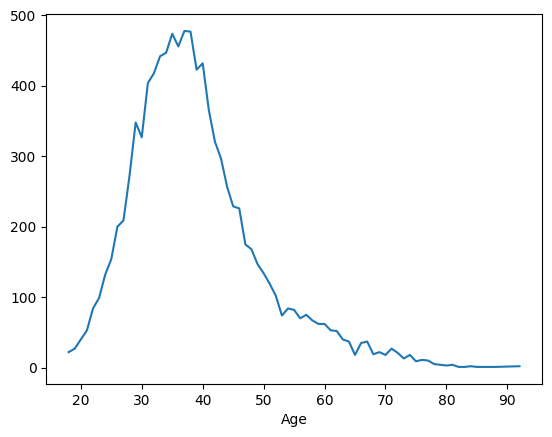

In [18]:
data["Age"].value_counts().sort_index(ascending = True).plot()
# Same
# plt.plot(data["Age"].value_counts().sort_index())

<Axes: xlabel='Age'>

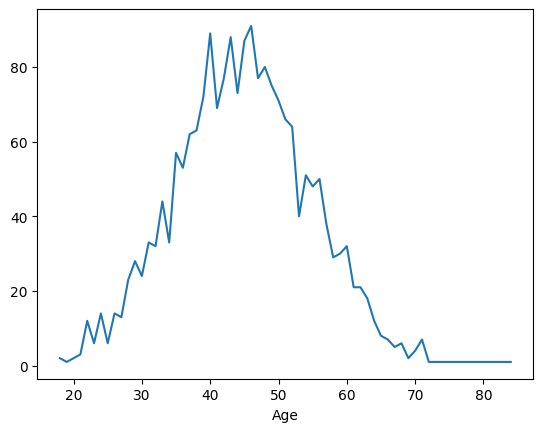

In [19]:
new_data = data.loc[data["Exited"] == 1]
new_data["Age"].value_counts().sort_index().plot()

In [20]:
# # KDE Plot 
# Tot = sns.kdeplot(data.Age[(data.Exited == 0)], color = "Red", fill = True)
# Tot = sns.kdeplot(data.Age[(data.Exited == 1)], color = "Blue", fill = True)
# Tot.legend(["No Churn", "Churn"], loc="upper right")
# Tot.set_ylabel("Density")
# Tot.set_xlabel("Age")
# Tot.set_title("Age by Density")

Text(0.5, 1.0, 'Age By Densitiy')

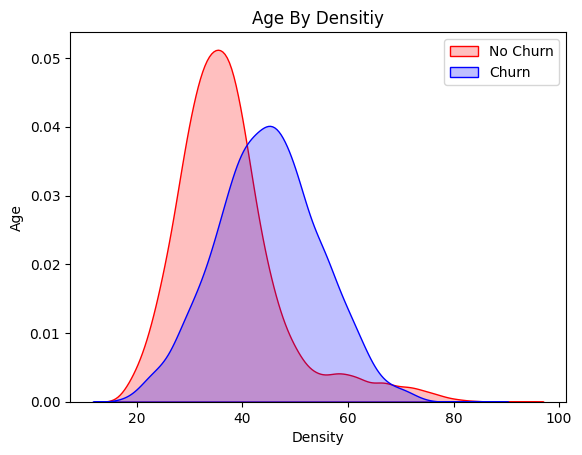

In [28]:
# Kde Plot 
tot = sns.kdeplot(data.Age[(data.Exited == 0)], color = "Red", fill = True)
tot = sns.kdeplot(data.Age[(data.Exited == 1)], fill = True, color = "Blue")
tot.legend(["No Churn", "Churn"], loc = "upper right")
tot.set_xlabel("Density")
tot.set_ylabel("Age")
tot.set_title("Age By Densitiy")

Text(0.5, 1.0, 'Age By Densitiy')

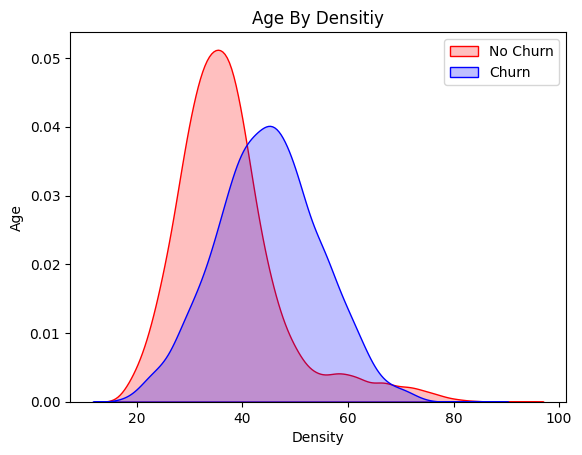

In [31]:
tot = sns.kdeplot(data.Age[(data["Exited"] == 0)], fill = True, color = "red")
tot = sns.kdeplot(data.Age[(data["Exited"] == 1)], fill = True, color = "blue")
tot.legend(["No Churn", "Churn"], loc = "upper right")
tot.set_xlabel("Density")
tot.set_ylabel("Age")
tot.set_title("Age By Densitiy")